# GestDeck - Cuaderno 01: Recopilación, Limpieza, EDA y Transformación del Dataset

Este cuaderno documenta todo el ciclo de vida inicial de los datos (ETL) para el proyecto académico **GestDeck**. El objetivo es procesar secuencias de video en bruto, analizarlas, extraer características topológicas usando MediaPipe, limpiar anomalías y preparar un dataset final enriquecido (aumentado) y debidamente particionado para el entrenamiento de una red neuronal profunda LSTM.

In [1]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import mediapipe as mp
import json
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split

# Configuraciones visuales
sns.set_theme(style="whitegrid")

# Variables Globales
RAW_DATA_DIR = "../dataset/raw_videos"
PROCESSED_DIR = "../dataset/processed" # Datos Crudos de MediaPipe
FINAL_DATA_DIR = "../dataset/final"    # Datos Listos para la LSTM

SEQUENCE_LENGTH = 30
FEATURES = 42

for d in [PROCESSED_DIR, FINAL_DATA_DIR]:
    os.makedirs(d, exist_ok=True)

## 1. Detalle de Fuentes de Datos y Análisis Exploratorio de Videos

**Fuente de Datos**: El dataset primario consta de grabaciones de video propias generadas específicamente para este proyecto. Las muestras han sido catalogadas en subcarpetas de acuerdo con la clase de gesto correspondiente.
**Volumen Total Esperado**: 9 clases × 20 videos = 180 muestras independientes.

In [2]:
classes = [d for d in os.listdir(RAW_DATA_DIR) if os.path.isdir(os.path.join(RAW_DATA_DIR, d))]
video_stats = []

for cls in classes:
    class_dir = os.path.join(RAW_DATA_DIR, cls)
    videos = glob.glob(os.path.join(class_dir, "*.mp4")) + glob.glob(os.path.join(class_dir, "*.avi"))
    
    for v_path in videos:
        cap = cv2.VideoCapture(v_path)
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps = cap.get(cv2.CAP_PROP_FPS)
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        cap.release()
        
        duration = frame_count / fps if fps > 0 else 0
        video_stats.append({
            'Clase': cls,
            'Ruta': v_path,
            'Resolución': f"{width}x{height}",
            'FPS': round(fps, 2),
            'Frames_Totales': frame_count,
            'Duracion_Segundos': round(duration, 2)
        })

df_videos = pd.DataFrame(video_stats)
print(f"Volumen total de muestra: {len(df_videos)} videos encontrados.")
df_videos.head()

Volumen total de muestra: 447 videos encontrados.


,Clase,Ruta,Resolución,FPS,Frames_Totales,Duracion_Segundos
0,ANTERIOR,../dataset/raw_videos\ANTERIOR\VIDEO_ANTERIOR_...,640x360,15.18,35,2.31
1,ANTERIOR,../dataset/raw_videos\ANTERIOR\VIDEO_ANTERIOR_...,640x360,15.25,31,2.03
2,ANTERIOR,../dataset/raw_videos\ANTERIOR\VIDEO_ANTERIOR_...,640x360,15.19,36,2.37
3,ANTERIOR,../dataset/raw_videos\ANTERIOR\VIDEO_ANTERIOR_...,640x360,15.08,42,2.79
4,ANTERIOR,../dataset/raw_videos\ANTERIOR\VIDEO_ANTERIOR_...,640x360,15.11,45,2.98


C:\Users\Carlos Ahumada Soles\AppData\Local\Temp\ipykernel_9092\1246501402.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_videos, y='Clase', order=df_videos['Clase'].value_counts().index, palette='viridis')


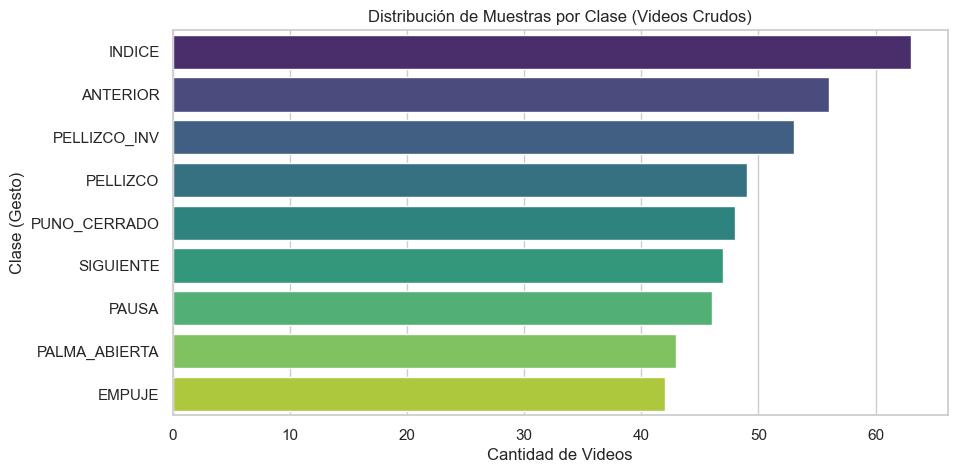


--- Estadísticas Descriptivas (Resoluciones y Duraciones) ---


,FPS,Frames_Totales,Duracion_Segundos
count,447.000000,447.000000,447.000000
mean,15.367226,30.706935,2.004251
std,1.403075,7.913009,0.516236
min,15.020000,11.000000,0.710000
25%,15.145000,25.000000,1.630000
50%,15.210000,30.000000,1.910000
75%,15.280000,36.000000,2.370000
max,29.990000,63.000000,4.190000


Resolución
1280x720    267
640x360     180
Name: count, dtype: int64

In [3]:
# Distribución de clases
plt.figure(figsize=(10, 5))
sns.countplot(data=df_videos, y='Clase', order=df_videos['Clase'].value_counts().index, palette='viridis')
plt.title('Distribución de Muestras por Clase (Videos Crudos)')
plt.xlabel('Cantidad de Videos')
plt.ylabel('Clase (Gesto)')
plt.show()

# Estadísticas descriptivas de las entradas crudas
print("\n--- Estadísticas Descriptivas (Resoluciones y Duraciones) ---")
display(df_videos.describe())
display(df_videos['Resolución'].value_counts())

## 2. Extracción de Características (MediaPipe Pipeline)

El procesamiento directo de matrices de píxeles (videos en bruto) hacia un modelo profundo requiere un volumen de datos masivo. Para abordar nuestra escasez de datos (180 videos), introducimos un **Feature Extractor preentrenado (MediaPipe)**.

**Justificación:** MediaPipe procesa cada frame y extrae las coordenadas `(x, y)` espaciales de 21 landmarks de la mano, omitiendo la textura, iluminación y fondo. Esto transforma nuestro tensor 4D `(muestras, frames, ancho, alto, canales)` en un tensor 3D numéricamente ligero `(muestras, frames=30, features=42)`.

In [4]:
import urllib.request
import os

# Descargar el modelo requerido por la nueva API de MediaPipe (Tasks)
model_path = "hand_landmarker.task"
if not os.path.exists(model_path):
    print("Descargando modelo HandLandmarker de MediaPipe...")
    url = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
    urllib.request.urlretrieve(url, model_path)
    print("Modelo descargado.")

from mediapipe.tasks import python
from mediapipe.tasks.python import vision

base_options = python.BaseOptions(model_asset_path=model_path)
options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=1,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5
)
detector = vision.HandLandmarker.create_from_options(options)

def extract_features(video_path):
    cap = cv2.VideoCapture(video_path)
    frames_features = []
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
            
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        # Convertir a imagen de MediaPipe
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
        
        results = detector.detect(mp_image)
        
        if results.hand_landmarks:
            features = []
            for lm in results.hand_landmarks[0]:
                features.extend([lm.x, lm.y])
            frames_features.append(features)
        else:
            # Frame vacío/sin detección
            frames_features.append(np.zeros(FEATURES).tolist())
            
    cap.release()
    if not frames_features: return None
        
    frames_features = np.array(frames_features)
    
    # Estandarización a SEQUENCE_LENGTH
    if len(frames_features) > SEQUENCE_LENGTH:
        frames_features = frames_features[:SEQUENCE_LENGTH]
    elif len(frames_features) < SEQUENCE_LENGTH:
        pad = np.zeros((SEQUENCE_LENGTH - len(frames_features), FEATURES))
        frames_features = np.vstack((frames_features, pad))
        
    return frames_features

# Extracción Batch
dataset_index = {}
for cls in classes:
    class_dir = os.path.join(RAW_DATA_DIR, cls)
    videos = glob.glob(os.path.join(class_dir, "*.mp4")) + glob.glob(os.path.join(class_dir, "*.avi"))
    
    class_data = []
    for v in videos:
        feat = extract_features(v)
        if feat is not None:
            class_data.append(feat)
            
    if class_data:
        class_data_np = np.array(class_data)
        out_path = os.path.join(PROCESSED_DIR, f"{cls}.npy")
        np.save(out_path, class_data_np)
        dataset_index[cls] = out_path
        
with open(os.path.join(PROCESSED_DIR, "dataset_index.json"), "w") as f:
    json.dump(dataset_index, f)

print("¡Vectores extraídos con éxito!")


¡Vectores extraídos con éxito!


## 3. EDA Avanzado y Detección de Anomalías (Vectores)

Una vez convertidos los videos a vectores, analizamos la integridad y calidad de la extracción.

Shape de los datos crudos extraídos: (447, 30, 42)

Media general de coordenadas: 0.4723
Desviación estándar de coordenadas: 0.2206


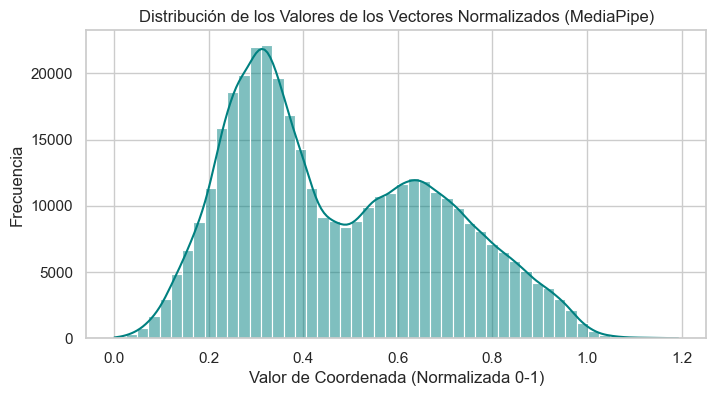

In [5]:
X_raw, y_raw = [], []
for i, cls in enumerate(classes):
    if cls in dataset_index:
        data = np.load(dataset_index[cls])
        X_raw.append(data)
        y_raw.extend([i] * len(data))
        
X_raw = np.concatenate(X_raw, axis=0)
y_raw = np.array(y_raw)

print(f"Shape de los datos crudos extraídos: {X_raw.shape}")

# Estadísticas Descriptivas del tensor
mean_vals = np.mean(X_raw[X_raw > 0]) # Excluimos ceros de la media
std_vals = np.std(X_raw[X_raw > 0])
print(f"\nMedia general de coordenadas: {mean_vals:.4f}")
print(f"Desviación estándar de coordenadas: {std_vals:.4f}")

# Histograma de densidades de coordenadas (Ignorando 0,0 absoluto)
plt.figure(figsize=(8, 4))
sns.histplot(X_raw[X_raw > 0].flatten(), bins=50, kde=True, color='teal')
plt.title('Distribución de los Valores de los Vectores Normalizados (MediaPipe)')
plt.xlabel('Valor de Coordenada (Normalizada 0-1)')
plt.ylabel('Frecuencia')
plt.show()

## 4. Pipeline de Limpieza (Data Cleaning)

**Criterio de Exclusión**: Se descartan las secuencias (videos) donde el tracker falló considerablemente.
- Tolerancia: Máximo 5 frames vacíos de los 30 estipulados.

**Impacto del Criterio**: A continuación visualizaremos cuántas muestras sobrepasaron la limpieza.

C:\Users\Carlos Ahumada Soles\AppData\Local\Temp\ipykernel_9092\2154081088.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=impact_data, x='Fase', y='Muestras', palette='Reds')


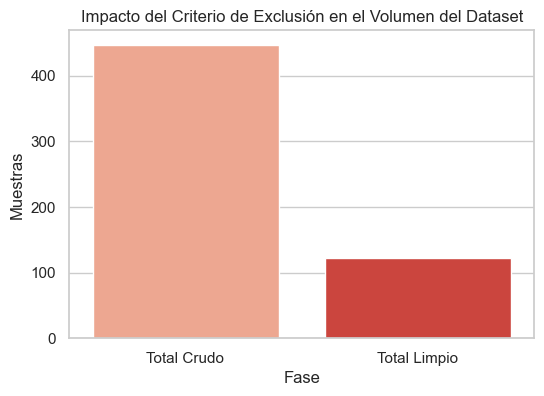

Muestras descartadas: 325


In [6]:
MAX_EMPTY = 5
X_clean, y_clean = [], []

for sample, label in zip(X_raw, y_raw):
    empty_frames = np.sum(np.all(sample == 0, axis=1))
    if empty_frames <= MAX_EMPTY:
        X_clean.append(sample)
        y_clean.append(label)

X_clean, y_clean = np.array(X_clean), np.array(y_clean)

# Análisis de Impacto
impact_data = pd.DataFrame({
    'Fase': ['Total Crudo', 'Total Limpio'],
    'Muestras': [len(X_raw), len(X_clean)]
})

plt.figure(figsize=(6, 4))
sns.barplot(data=impact_data, x='Fase', y='Muestras', palette='Reds')
plt.title('Impacto del Criterio de Exclusión en el Volumen del Dataset')
plt.show()
print(f"Muestras descartadas: {len(X_raw) - len(X_clean)}")

## 5. Partición del Dataset (Stratified Split)

Al tener un volumen reducido (20 videos por clase originarios, algunos descartados en limpieza), es crítico usar una **partición estratificada** para garantizar que tanto la etapa de validación como la de testing tengan presencia de *todas* las clases.

**Proporción**: 80% Train, 10% Validation, 10% Test.

In [7]:
# Primer split: Test (10%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_clean, y_clean, test_size=0.10, random_state=42, stratify=y_clean
)

# Segundo split: Train (80% del total) y Val (10% del total)
# Como el temp es 90% del dataset original, separar el 11.11% del temp nos da 10% del total real.
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=(0.10 / 0.90), random_state=42, stratify=y_temp
)

print("\n=== Resultados de la Partición Estratificada ===")
print(f"Conjunto de Entrenamiento: X={X_train.shape}, y={y_train.shape}")
print(f"Conjunto de Validación:    X={X_val.shape}, y={y_val.shape}")
print(f"Conjunto de Prueba (Test): X={X_test.shape}, y={y_test.shape}")


=== Resultados de la Partición Estratificada ===
Conjunto de Entrenamiento: X=(96, 30, 42), y=(96,)
Conjunto de Validación:    X=(13, 30, 42), y=(13,)
Conjunto de Prueba (Test): X=(13, 30, 42), y=(13,)


## 6. Transformaciones y Aumentación de Datos (Data Augmentation)

**Normalización**:
- Los datos ya vienen normalizados estructuralmente por el modelo Hand Landmarks de MediaPipe (rango estático dinámico basado en la bounding box de la mano). Esta normalización **siempre aplica** tanto en entrenamiento como en inferencia.

**Aumentación (SÓLO para Entrenamiento)**:
- Dado que el conjunto de Validación tiene extremadamente pocos ejemplos (aprox 2 por clase), la red es propensa al *overfitting*. 
- Aplicaremos perturbaciones al conjunto de *Train* exclusivamente, aumentando artificialmente el volumen en $3x$ introduciendo:
  1. **Spatial Jittering** (Ruido Gaussiano, $p=1.0$ en la copia 1): Simula vibraciones de cámara.
  2. **Spatial Scaling** (Zoom In/Out, $p=1.0$ en la copia 2): Simula a la persona acercándose o alejándose del lente.

*(Nota: El Validation set y el Test set NO se alteran)*

In [8]:
def augment_train_set(X, y):
    X_aug, y_aug = [], []
    for x_sample, label in zip(X, y):
        mask = (x_sample != 0).astype(float) # Protege los frames vacíos (0)
        
        # 1. Copia Original
        X_aug.append(x_sample)
        y_aug.append(label)
        
        # 2. Ruido Gaussiano (Std dev controlada)
        noise = np.random.normal(loc=0.0, scale=0.003, size=x_sample.shape)
        X_aug.append(x_sample + (noise * mask))
        y_aug.append(label)
        
        # 3. Escalado Espacial 
        scale_factor = np.random.uniform(0.9, 1.1)
        x_scaled = ((x_sample - 0.5) * scale_factor + 0.5) * mask
        X_aug.append(x_scaled)
        y_aug.append(label)
        
    return np.array(X_aug), np.array(y_aug)

X_train_aug, y_train_aug = augment_train_set(X_train, y_train)

print("=== Aumentación de Datos (Train Set Only) ===")
print(f"Volumen Entrenamiento Original: {X_train.shape[0]} secuencias")
print(f"Volumen Entrenamiento Aumentado (3x): {X_train_aug.shape[0]} secuencias")

# Guardado final para el Modelo
np.save(os.path.join(FINAL_DATA_DIR, "X_train.npy"), X_train_aug)
np.save(os.path.join(FINAL_DATA_DIR, "y_train.npy"), y_train_aug)
np.save(os.path.join(FINAL_DATA_DIR, "X_val.npy"), X_val)
np.save(os.path.join(FINAL_DATA_DIR, "y_val.npy"), y_val)
np.save(os.path.join(FINAL_DATA_DIR, "X_test.npy"), X_test)
np.save(os.path.join(FINAL_DATA_DIR, "y_test.npy"), y_test)
with open(os.path.join(FINAL_DATA_DIR, "labels.json"), "w") as f:
    json.dump(classes, f, indent=4)

print("\n¡Todo el Data Pipeline ha finalizado! Los tensores estratificados y aumentados están listos en `dataset/final/`")

=== Aumentación de Datos (Train Set Only) ===
Volumen Entrenamiento Original: 96 secuencias
Volumen Entrenamiento Aumentado (3x): 288 secuencias

¡Todo el Data Pipeline ha finalizado! Los tensores estratificados y aumentados están listos en `dataset/final/`
